# Notebook 3: Exploratory Data Analysis (EDA)

Superstore-Data-Analysis 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

df = pd.read_csv('D:\project_sales\project_for_DA/cleaned_retail_sales.csv', parse_dates=['Order_Date','Ship_Date'])
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Month_Name,Order_Quarter,Order_Day,Weekday,Is_Weekend,Sales_per_Quantity,Profit_Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,8,Tuesday,0,130.9800,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,8,Tuesday,0,243.9800,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,12,Sunday,1,7.3100,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,11,Sunday,1,191.5155,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,11,Sunday,1,11.1840,11.25


In [2]:
print(df.shape)
df.info()

(9994, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row_ID              9994 non-null   int64         
 1   Order_ID            9994 non-null   object        
 2   Order_Date          9994 non-null   datetime64[ns]
 3   Ship_Date           9994 non-null   datetime64[ns]
 4   Ship_Mode           9994 non-null   object        
 5   Customer_ID         9994 non-null   object        
 6   Customer_Name       9994 non-null   object        
 7   Segment             9994 non-null   object        
 8   Country             9994 non-null   object        
 9   City                9994 non-null   object        
 10  State               9994 non-null   object        
 11  Postal_Code         9994 non-null   int64         
 12  Region              9994 non-null   object        
 13  Product_ID          9994 non-null   o

In [3]:
print('Total Sales:', df['Sales'].sum())
print('Total Profit:', df['Profit'].sum())
print('Total Orders:', len(df))
print('Total Customers:', df['Customer_ID'].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 9994
Total Customers: 793


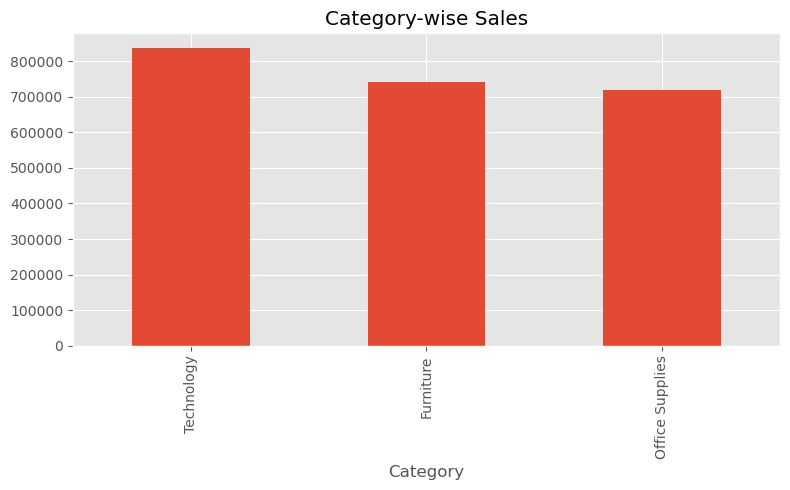

In [4]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Category-wise Sales')
plt.tight_layout()
plt.show()

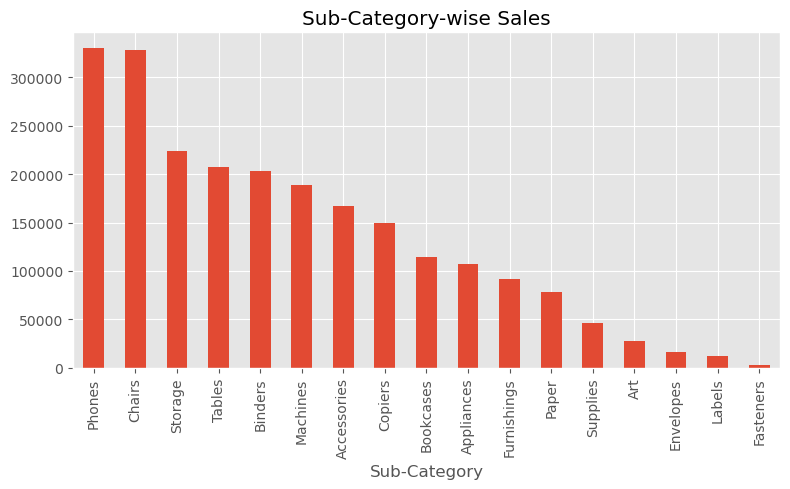

In [5]:
plt.figure(figsize=(8,5))
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Sub-Category-wise Sales')
plt.tight_layout()
plt.show()

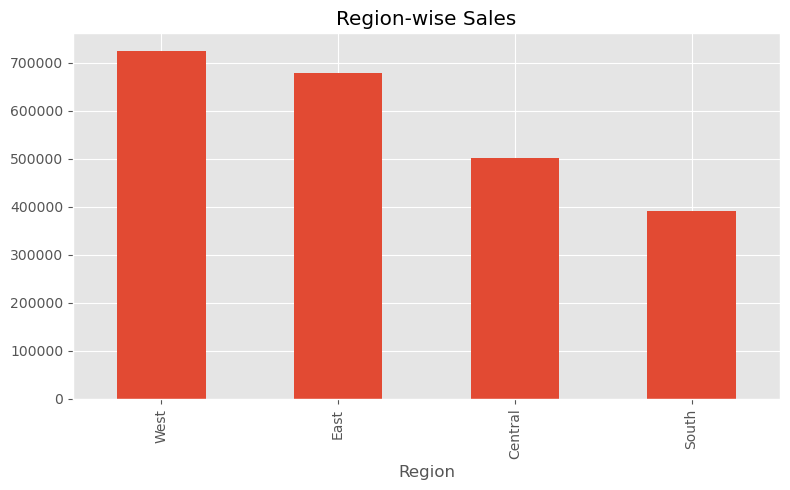

In [6]:
plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Region-wise Sales')
plt.tight_layout()
plt.show()

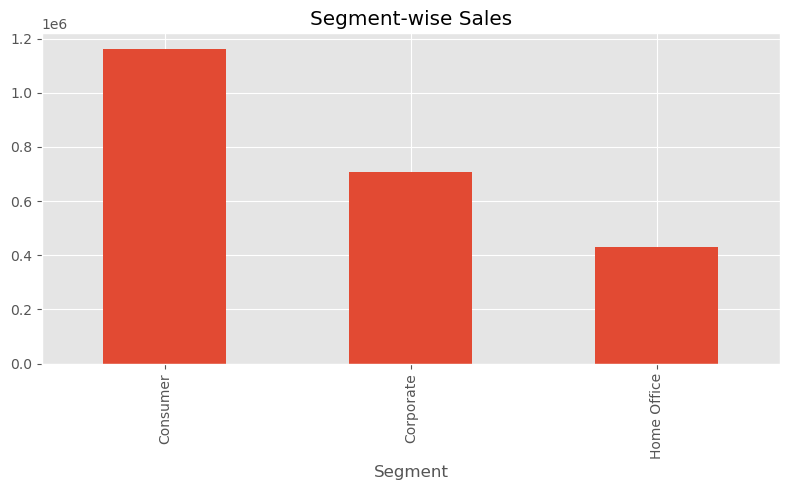

In [7]:
plt.figure(figsize=(8,5))
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Segment-wise Sales')
plt.tight_layout()
plt.show()

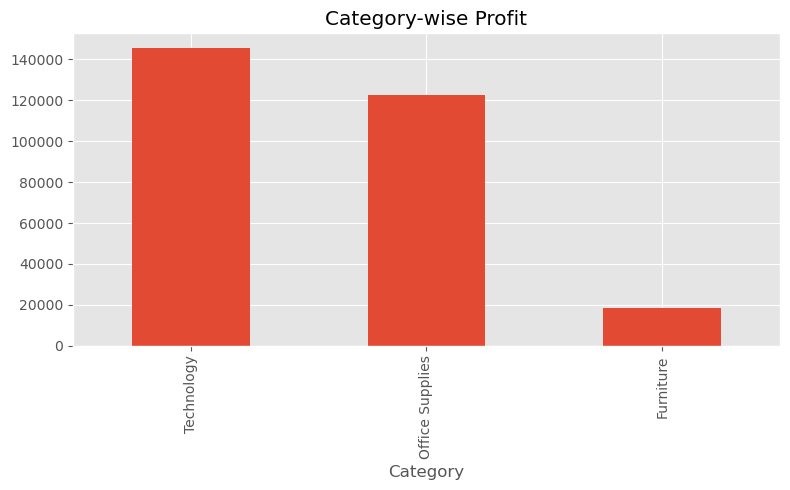

In [8]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Profit'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Category-wise Profit')
plt.tight_layout()
plt.show()

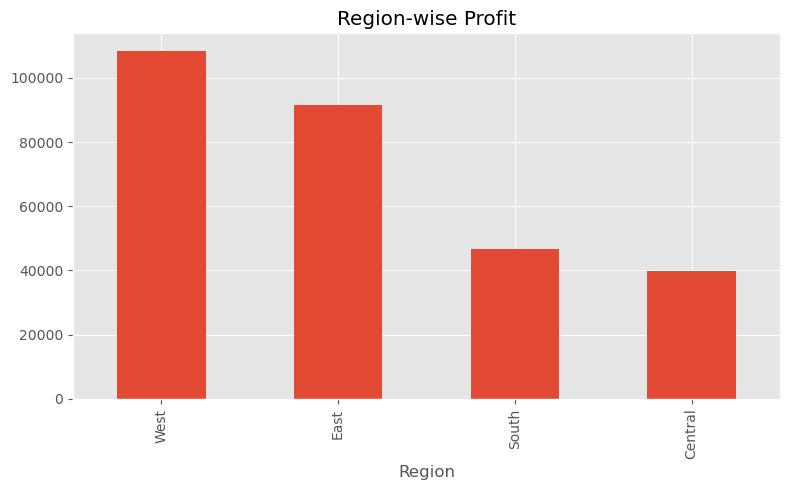

In [9]:
plt.figure(figsize=(8,5))
df.groupby('Region')['Profit'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Region-wise Profit')
plt.tight_layout()
plt.show()

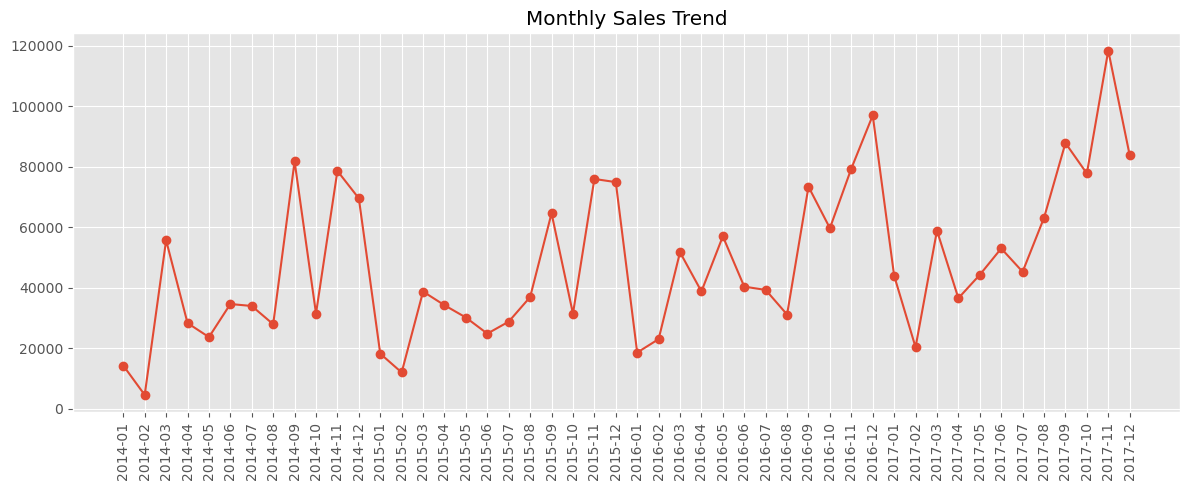

In [10]:
monthly=df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly.index=monthly.index.astype(str)
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

C:\Users\SRI\AppData\Local\Temp\ipykernel_12608\2368308105.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


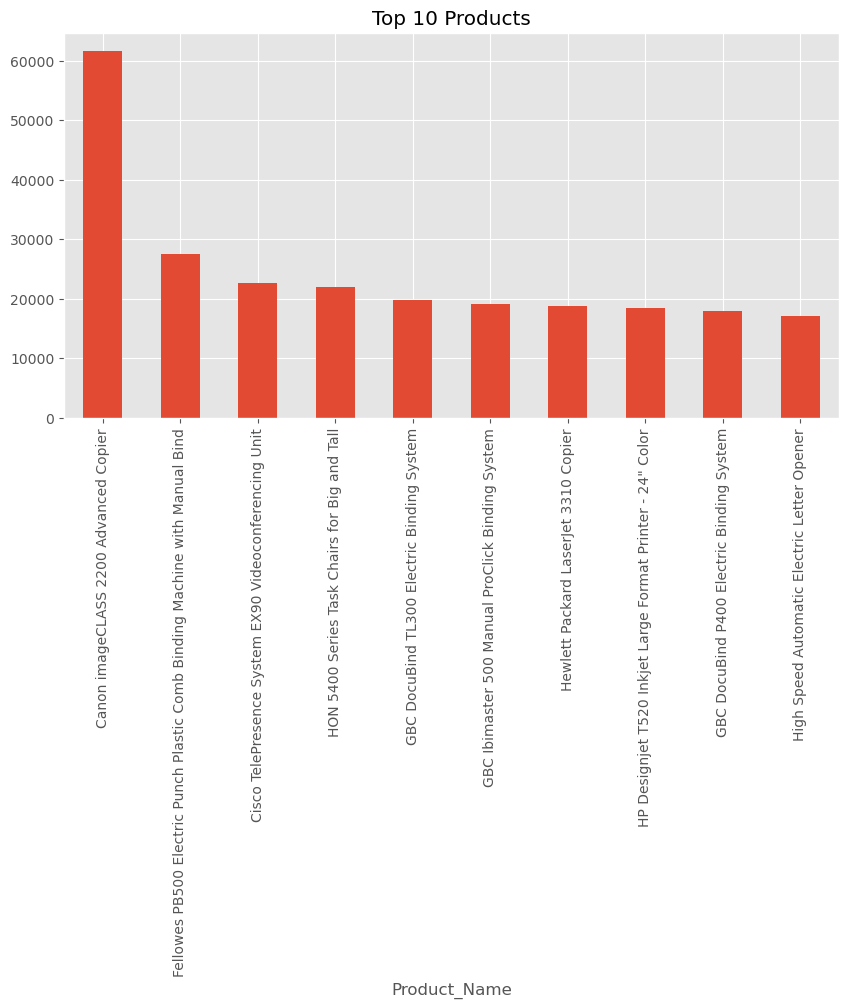

In [11]:
top10=df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 Products')
plt.tight_layout()
plt.show()

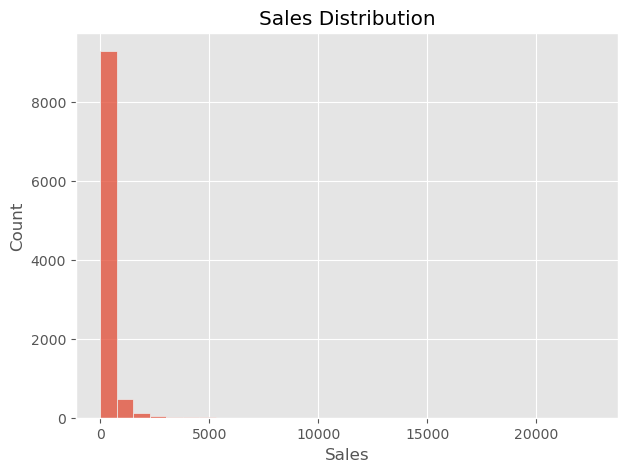

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.show()

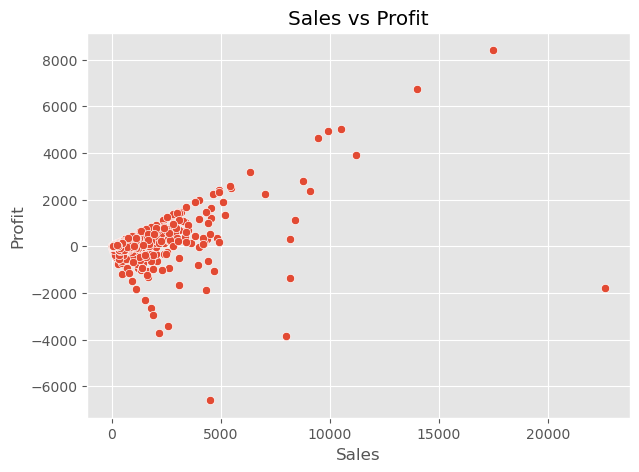

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x='Sales',y='Profit')
plt.title('Sales vs Profit')
plt.show()

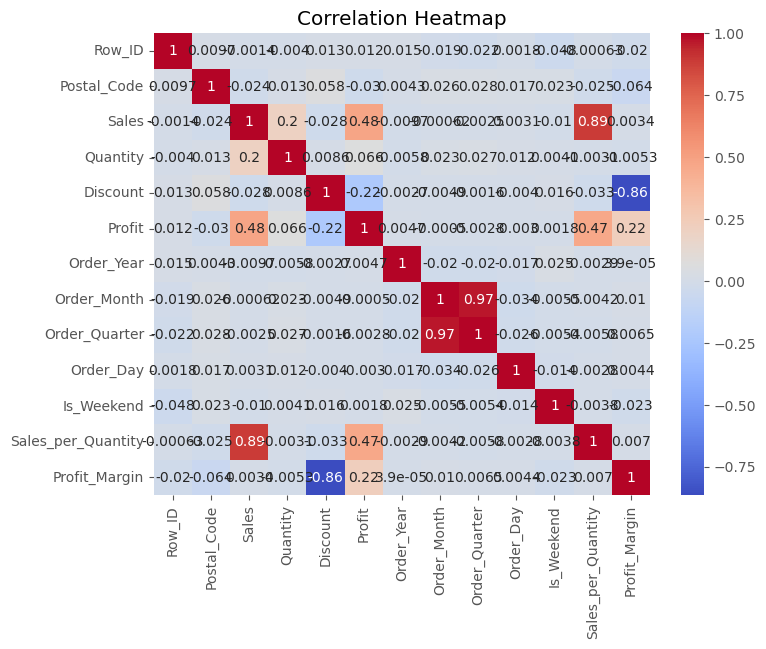

In [14]:
corr=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
summary=pd.DataFrame({
'Metric':['Total Sales','Total Profit','Average Sales','Average Profit','Orders','Customers','Products'],
'Value':[df['Sales'].sum(),df['Profit'].sum(),df['Sales'].mean(),df['Profit'].mean(),len(df),df['Customer_ID'].nunique(),df['Product_Name'].nunique()]
})
summary

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Average Sales,2.298580e+02
3,Average Profit,2.865690e+01
4,Orders,9.994000e+03
5,Customers,7.930000e+02
6,Products,1.850000e+03


In [17]:
summary.to_csv('D:\project_sales\project_for_DA/eda_summary1.csv',index=False)
print('EDA summary saved.')

EDA summary saved.
